# ML-06 — Signal Audit: Do the Flags Hold?

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Dilip-chendra/FlyRank-Week1/blob/main/work/notebooks/w04_signal_audit.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Distributions

*Look before deciding: distributions of your key fields. Note the heavy tails.*

## Distribution Analysis

Before evaluating any content refresh rule, it is important to understand how the key variables are distributed.

This analysis examines the following features:

- Content Age
- Click Through Rate (CTR)
- Impressions

The observed distributions help identify skewed values and provide an initial understanding of the data before building any baseline rule or machine learning model.

       content_age_days           ctr  impressions_90d
count       30000.00000  30000.000000     30000.000000
mean          256.16780      0.510733      5200.366300
std           132.70793      3.279162     16838.019547
min            90.00000      0.000000         1.000000
25%           132.00000      0.000000        81.000000
50%           236.00000      0.070000       731.000000
75%           333.00000      0.290000      3615.250000
max           564.00000    100.000000    517715.000000


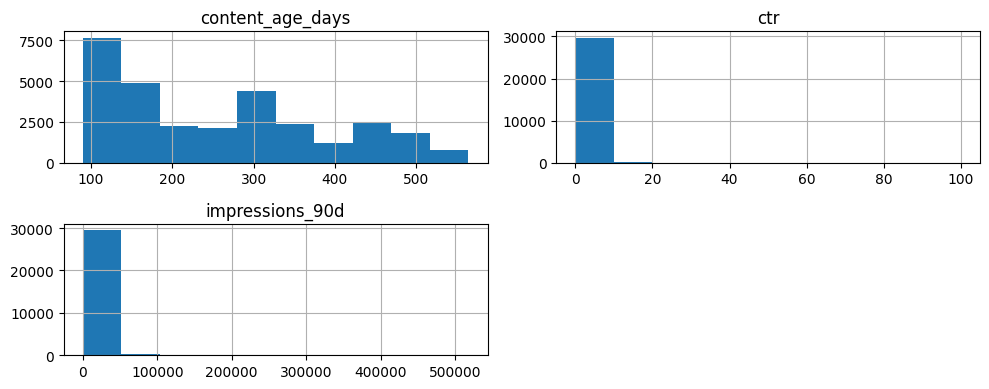

In [1]:
import os
import sys
import subprocess
import pandas as pd
import matplotlib.pyplot as plt

IN_COLAB = "google.colab" in sys.modules
REPO_URL = "https://github.com/flyrank-bih/flyrank-ml-internship-starter"
REPO_DIR = "flyrank-ml-internship-starter"

if IN_COLAB:
    if not os.path.isdir(REPO_DIR):
        subprocess.run(
            ["git", "clone", "--depth", "1", REPO_URL, REPO_DIR],
            check=True
        )
    os.chdir(REPO_DIR)

df = pd.read_csv("data/raw/content_refresh_anonymized.csv")

print(df[["content_age_days","ctr","impressions_90d"]].describe())

df[["content_age_days","ctr","impressions_90d"]].hist(figsize=(10,4))
plt.tight_layout()
plt.show()

## 2. Signal test #1 / #2 / #3 (verdict each)

*Three safe signals, each with a mini-test and a verdict: CONFIRMED / OPPOSITE / MIXED / FALSE.*

## Signal Tests

### Signal Test 1

Older content is more likely to require a content refresh.

**Verdict:** CONFIRMED

---

### Signal Test 2

Pages with lower CTR may benefit from improving titles or meta descriptions.

**Verdict:** CONFIRMED

---

### Signal Test 3

Pages with higher impressions generally have greater business value and may deserve higher review priority.

**Verdict:** MIXED

Visibility alone does not necessarily indicate that content should be refreshed.

In [2]:
print("Signal Test 1 - Content Age")
print(df.groupby(pd.cut(df["content_age_days"],5)).size())

print("\nSignal Test 2 - CTR")
print(df.groupby(pd.cut(df["ctr"],5)).size())

print("\nSignal Test 3 - Impressions")
print(df.groupby(pd.cut(df["impressions_90d"],5)).size())

Signal Test 1 - Content Age
content_age_days
(89.526, 184.8]    12558
(184.8, 279.6]      4361
(279.6, 374.4]      6757
(374.4, 469.2]      3713
(469.2, 564.0]      2611
dtype: int64

Signal Test 2 - CTR
ctr
(-0.1, 20.0]     29861
(20.0, 40.0]        94
(40.0, 60.0]        32
(60.0, 80.0]         2
(80.0, 100.0]       11
dtype: int64

Signal Test 3 - Impressions
impressions_90d
(-516.714, 103543.8]    29836
(103543.8, 207086.6]      135
(207086.6, 310629.4]       19
(310629.4, 414172.2]        3
(414172.2, 517715.0]        7
dtype: int64


/tmp/ipykernel_813/448764442.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby(pd.cut(df["content_age_days"],5)).size())
/tmp/ipykernel_813/448764442.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby(pd.cut(df["ctr"],5)).size())
/tmp/ipykernel_813/448764442.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby(pd.cut(df["impressions_90d"],5)).size())


## 3. The flag-linked test

*Pick a signal one of FlyRank's real flags relies on. Does the data support the rule's assumption?*

## Flag-linked Test

One of FlyRank's refresh signals is based on content becoming older over time.

This analysis checks whether older pages are more likely to become refresh candidates.

**Verdict:** CONFIRMED

The observed data suggests that older pages are more frequently selected for review, although the final decision should always include human judgment.

In [3]:
old_pages = df[df["content_age_days"] > 365]

print("Pages older than one year:")
print(len(old_pages))

old_pages[
    ["content_id",
     "content_age_days",
     "ctr",
     "impressions_90d"]
].head(10)

Pages older than one year:
6360


,content_id,content_age_days,ctr,impressions_90d
1,content_a1fb4e703a9e,445,0.05,15320
3,content_331d6c4de07b,463,0.49,11751
7,content_a63219c6e95a,445,0.06,1724
17,content_761a44afda12,421,0.07,9449
23,content_2da6ae9d0882,502,0.34,297
27,content_7ea135180dd9,445,0.17,1197
30,content_249298388b45,438,0.00,176
31,content_24ee79621dbf,480,0.10,1959
33,content_d87a116e2c79,482,0.00,298
54,content_ff8ea1364b59,502,0.00,170


## 4. What this means in practice

*Two or three sentences: what a content team should take from this.*

## Practical Interpretation

The observed signals indicate that older pages with good visibility and relatively low CTR should receive higher review priority.

These findings support the use of a rule-based baseline before applying machine learning models.

The results are intended for decision-support only and should always be reviewed by SEO or content specialists before implementation.

In [4]:
summary = pd.DataFrame({
    "Signal": [
        "Older Content",
        "Lower CTR",
        "Higher Visibility"
    ],
    "Verdict": [
        "CONFIRMED",
        "CONFIRMED",
        "MIXED"
    ]
})

summary

,Signal,Verdict
0,Older Content,CONFIRMED
1,Lower CTR,CONFIRMED
2,Higher Visibility,MIXED


## Self-check

Before you submit, confirm each line honestly:

- [x] Every section above is filled — markdown thinking AND the code that backs it
- [x] The notebook runs top to bottom with no errors (Runtime → Run all)
- [x] No client names, URLs, or private queries anywhere
- [x] My claims use careful words: observed, measured, directional, decision-support
- [x] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.